<a href="https://colab.research.google.com/github/fourmodern/2025_aidrugdiscovery/blob/main/Day1/T005_Ligand_Pharmacophore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# T009 · 리간드 기반 약물작용점

**참고:** 이 talktorial은 도메인별 기술을 가르치고 연구 프로젝트의 시작점으로 파이프라인 템플릿을 제공하는 것을 목표로 하는 플랫폼인 TeachOpenCADD의 일부입니다.

저자:

- Pratik Dhakal, CADD seminar, 2017, Charité/FU Berlin
- Florian Gusewski, CADD seminar, 2018, Charité/FU Berlin
- Jaime Rodríguez-Guerra, [Volkamer lab](https://volkamerlab.org/), Charité
- Dominique Sydow, [Volkamer lab](https://volkamerlab.org/), Charité

__Talktorial T009__: 이 talktorial은 talktorials T001-T010으로 구성된 [첫 번째 TeachOpenCADD 논문](https://jcheminf.biomedcentral.com/articles/10.1186/s13321-019-0351-x)에 설명된 TeachOpenCADD 파이프라인의 일부입니다.

**참고**: 이 노트북을 셀별로 실행해주세요. 모든 셀을 한번에 실행하는 것도 가능하지만, nglview 3D 표현의 일부가 누락될 수 있습니다.

## 이 talktorial의 목표

이 talktorial에서는 이전 talktorial에서 선택되고 정렬된 알려진 EGFR 리간드를 사용하여 각 리간드의 공여체, 수용체, 그리고 소수성 약물작용점 특징을 식별합니다. 그런 다음 이러한 특징들을 클러스터링하여 알려진 EGFR 리간드 세트의 특성을 나타내고 가상 스크리닝을 통해 새로운 EGFR 리간드를 검색하는 데 사용할 수 있는 앙상블 약물작용점을 정의합니다.

## 학습 목표

### *이론* 내용

* 약물작용점 모델링
  * 구조 기반 및 리간드 기반 약물작용점 모델링
* 약물작용점을 사용한 가상 스크리닝
* 클러스터링: k-means

### *실습* 내용

* 이전 talktorial에서 미리 정렬된 리간드 가져오기
* NGLView로 리간드 표시하기
* 약물작용점 특징 추출
* 모든 리간드의 약물작용점 특징 표시
  * 수소결합 공여체
  * 수소결합 수용체
  * 소수성 접촉
* 특징 유형별 특징 좌표 수집
* 앙상블 약물작용점 생성
  * k-means 클러스터링을 위한 정적 매개변수 설정
  * 클러스터 선택을 위한 정적 매개변수 설정
  * k-means 클러스터링 및 클러스터 선택 함수 정의
  * 특징 클러스터링
  * 관련 클러스터 선택
  * 선택된 클러스터 좌표 가져오기
* 클러스터 표시
  * 수소결합 공여체
  * 수소결합 수용체
  * 소수성 접촉
* 앙상블 약물작용점 표시

### 참고문헌

* IUPAC 약물작용점 정의
([<i>Pure & Appl. Chem</i> (1998), <b>70</b>, 1129-43](https://www.degruyter.com/view/journals/pac/70/5/article-p1129.xml))
* LigandScout의 3D 약물작용점
([<i>J. Chem. Inf. Model.</i> (2005), <b>45</b>, 160-9](https://pubs.acs.org/doi/10.1021/ci049885e))
* 책 챕터: 약물작용점 인식 및 응용
([Applied Chemoinformatics, Wiley-VCH Verlag GmbH & Co. KGaA, Weinheim, (2018), **1**, 259-82](https://onlinelibrary.wiley.com/doi/10.1002/9783527806539.ch6f))
* 책 챕터: 구조 기반 가상 스크리닝 ([Applied Chemoinformatics, Wiley-VCH Verlag GmbH & Co. KGaA, Weinheim, (2018), **1**, 313-31](https://onlinelibrary.wiley.com/doi/10.1002/9783527806539.ch6h))
* Monty Kier와 약물작용점 개념의 기원
([<i>Internet Electron. J. Mol. Des.</i> (2007), <b>6</b>, 271-9](http://biochempress.com/Files/iejmd_2007_6_0271.pdf))
* Nik Stiefl의 RDKit을 사용한 약물작용점 모델링 데모
([GitHub의 RDKit UGM 2016](https://github.com/rdkit/UGM_2016/blob/master/Notebooks/Stiefl_RDKitPh4FullPublication.ipynb))

## 이론

### 약물작용점

컴퓨터 지원 약물 설계에서 약물작용점을 사용한 약물-표적 상호작용의 기술은 잘 정립된 방법입니다. 약물작용점이라는 용어는 1998년 IUPAC 작업반에 의해 정의되었습니다:
"약물작용점은 특정 생물학적 표적 구조와의 최적의 초분자적 상호작용을 보장하고 생물학적 반응을 촉발(또는 차단)하는 데 필요한 입체 및 전자적 특징의 집합체이다."
([<i>Pure & Appl. Chem.</i> (1998), <b>70</b>, 1129-43](https://www.degruyter.com/view/journals/pac/70/5/article-p1129.xml))

다시 말해서, *약물작용점*은 조사 중인 표적에 결합하는 것으로 관찰된 리간드의 중요한 입체 및 물리화학적 특성을 설명하는 여러 *약물작용점 특징*으로 구성됩니다.
이러한 *물리화학적 특성*(특징 유형이라고도 함)은 수소결합 공여체/수용체, 소수성/방향족 상호작용, 또는 양전하/음전하 그룹이 될 수 있으며, *입체 특성*은 이러한 특징들의 3D 배치에 의해 정의됩니다.

### 구조 기반 및 리간드 기반 약물작용점 모델링

약물작용점 모델링에서는 생물학적 질문과 이용 가능한 데이터 소스에 따라 두 가지 주요 접근법, 즉 구조 기반 및 리간드 기반 약물작용점 모델링이 사용됩니다.

*구조 기반 약물작용점 모델*은 단백질-리간드 복합체에서 유도됩니다. 특징들은 단백질과 리간드 간의 관찰된 상호작용에 의해 정의되며, 리간드 결합에 관여하는 것으로 이미 입증된 리간드 부분만 가상 스크리닝에 사용되도록 보장합니다.
그러나 모든 표적에 대해 단백질-리간드 복합체 구조를 이용할 수 있는 것은 아닙니다.
이 경우, 분자 도킹 등을 통해 리간드를 표적 결합 부위에 모델링하여 복합체 구조를 생성하거나, 표적 결합 부위만 사용하여 잠재적인 단백질-리간드 상호작용 부위를 탐지하는 약물작용점 모델링 방법을 사용할 수 있습니다.

*리간드 기반 약물작용점 모델*은 조사 중인 표적에 결합하는 것으로 알려진 리간드 세트를 기반으로 합니다. 이러한 리간드들의 공통 화학적 특징이 약물작용점 모델을 구축합니다. 이 방법은 여러 알려진 리간드를 가진 표적과 단백질-리간드 복합체 구조가 없는 경우에 사용됩니다. 이 talktorial에서는 알려진 EGFR 리간드 세트를 사용한 리간드 기반 약물작용점 모델링을 사용할 것입니다.

약물작용점 모델링에 대한 자세한 정보는 [Pharmacophore Perception and Applications: Applied Chemoinformatics, Wiley-VCH Verlag GmbH & Co. KGaA, Weinheim, (2018), **1**, 259-82](https://onlinelibrary.wiley.com/doi/10.1002/9783527806539.ch6f)와 [<i>J. Chem. Inf. Model.</i> (2005), <b>45</b>, 160-9](https://pubs.acs.org/doi/10.1021/ci049885e)를 추천합니다.

![단백질-리간드 상호작용을 나타내는 구조 기반 약물작용점 (그림: Dominique Sydow)](https://github.com/volkamerlab/teachopencadd/blob/master/teachopencadd/talktorials/T009_compound_ensemble_pharmacophores/images/target+ligand+pharma_3x_feather.png?raw=1)

*그림 1*: 단백질-리간드 상호작용을 나타내는 구조 기반 약물작용점. 그림 제작: Dominique Sydow.

### 약물작용점을 사용한 가상 스크리닝

**Talktorial 4**에서 앞서 설명했듯이, 가상 스크리닝(VS)은 조사 중인 표적(쿼리로 표현됨)에 결합할 가능성이 가장 높은 라이브러리의 작은 분자를 식별하기 위해 쿼리(예: 약물작용점 모델(T009) 또는 쿼리 화합물(T004))를 대규모 화합물 라이브러리에 대해 스크리닝하는 것을 설명합니다. 약물작용점 기반 가상 스크리닝에서는 화합물 라이브러리를 약물작용점 모델에 화합물별로 매칭하고 가장 잘 매칭되는 결과에 따라 순위를 매깁니다 ([Structure-Based Virtual Screening: Applied Chemoinformatics, Wiley-VCH Verlag GmbH & Co. KGaA, Weinheim, (2018), **1**, 313-31](https://onlinelibrary.wiley.com/doi/10.1002/9783527806539.ch6h)).

### 클러스터링: k-means

이 talktorial에서는 여러 리간드 기반 약물작용점의 특징점을 클러스터링하여 앙상블 약물작용점을 생성할 것입니다. 클러스터링 알고리즘은 데이터 세트를 k개의 클러스터로 클러스터링하는 것을 목표로 하는 k-means 클러스터링을 사용합니다:

1. k개의 서로 다른 중심점이 선택되고 데이터 세트의 각 점이 가장 가까운 중심점에 할당됩니다.
2. 현재 클러스터를 기반으로 새로운 중심점이 계산되고 데이터 세트의 각 점이 가장 가까운 중심점에 새로 할당됩니다.
3. 중심점이 안정화될 때까지 이 절차가 반복됩니다.

[위키피디아의 k-means](https://de.wikipedia.org/wiki/K-Means-Algorithmus)에 대한 자세한 정보.

## 실습

In [ ]:
!pip install -q rdkit
# 3D 시각화: nglview는 Colab에서 렌더링되지 않아 py3Dmol을 사용합니다
!pip install -q py3Dmol
!pip install -q scikit-learn

In [ ]:
import collections
from collections import Counter
from pathlib import Path
import operator
import time
import math

import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn import datasets, cluster

from rdkit import RDConfig, Chem, Geometry, DistanceGeometry
from rdkit.Chem import (
    ChemicalFeatures,
    rdDistGeom,
    Draw,
    rdMolTransforms,
    AllChem,
)
# 주의: rdkit.Chem.Draw.DrawingOptions 는 최신 RDKit에서 제거되었습니다.
# 이 노트북에서는 사용하지 않으므로 import 하지 않습니다.
from rdkit.Chem.Pharm3D import Pharmacophore, EmbedLib
from rdkit.Numerics import rdAlignment
import py3Dmol
import gc

현재 노트북의 경로를 설정합니다.

In [ ]:
HERE = Path(_dh[-1])
DATA = HERE / "data"

### 이전 talktorial에서 미리 정렬된 리간드 가져오기

이전 talktorial에서 정렬된 모든 리간드를 가져옵니다.

먼저, 모든 리간드 PDB 파일의 파일 경로를 가져옵니다.

In [ ]:
!wget https://github.com/volkamerlab/teachopencadd/raw/refs/heads/master/teachopencadd/talktorials/T008_query_pdb/data/5HG8_lig.pdb
!wget https://github.com/volkamerlab/teachopencadd/raw/refs/heads/master/teachopencadd/talktorials/T008_query_pdb/data/5UG8_lig.pdb
!wget https://github.com/volkamerlab/teachopencadd/raw/refs/heads/master/teachopencadd/talktorials/T008_query_pdb/data/5UG9_lig.pdb
!wget https://github.com/volkamerlab/teachopencadd/raw/refs/heads/master/teachopencadd/talktorials/T008_query_pdb/data/5UGC_lig.pdb
!wget https://github.com/volkamerlab/teachopencadd/raw/refs/heads/master/teachopencadd/talktorials/T008_query_pdb/data/PDB_top_ligands.csv


mol_files = sorted(Path(HERE).glob("*_lig.pdb"))
print([f.name for f in mol_files])

--2024-09-20 09:57:57--  https://github.com/volkamerlab/teachopencadd/raw/refs/heads/master/teachopencadd/talktorials/T008_query_pdb/data/5HG8_lig.pdb
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/volkamerlab/teachopencadd/refs/heads/master/teachopencadd/talktorials/T008_query_pdb/data/5HG8_lig.pdb [following]
--2024-09-20 09:57:57--  https://raw.githubusercontent.com/volkamerlab/teachopencadd/refs/heads/master/teachopencadd/talktorials/T008_query_pdb/data/5HG8_lig.pdb
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3309 (3.2K) [text/plain]
Saving to: ‘5HG8_lig.pdb.1’

5HG8_lig.pdb.1      100%

In [ ]:
# NBVAL_CHECK_OUTPUT
pdb_ids = [Path(file).stem.split("_")[0] for file in mol_files]
pdb_ids

['5HG8', '5UG8', '5UG9', '5UGC']

두 번째로, RDKit을 사용하여 이러한 PDB 파일에서 모든 리간드를 읽습니다.

In [ ]:
# NBVAL_CHECK_OUTPUT
molecules = []
for mol_file in mol_files:
    molecule = Chem.MolFromPDBFile(str(mol_file), removeHs=False)
    if molecule is None:
        print(mol_file, "Could not be read")
    else:
        Chem.SanitizeMol(molecule)
        print(Chem.MolToSmiles(molecule))
        molecules.append(molecule)
print(f"Number of molecules: {len(molecules)}")

CCC(O)NC1CCCC(OC2NC(NC3CNN(C)C3)NC3NCCC32)C1
CCC(O)NC1CN(C2NC(NC3CNN(C)C3)C3NCN(C(C)C)C3N2)CC1F
CCC(O)NC1CN(C2NC(NC3CN(C)NC3OC)C3NCN(C(C)C)C3N2)CC1F
CCC(O)NC1CN(C2NC(NC3CN(C)NC3OC)C3NCN(C)C3N2)CC1F
Number of molecules: 4


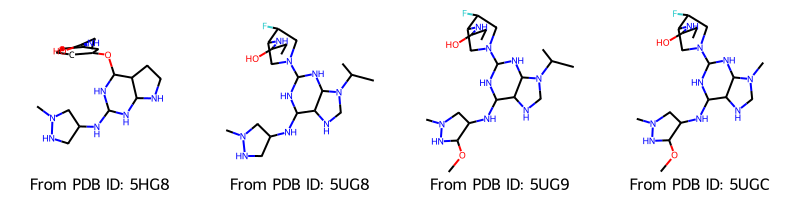

In [ ]:
Draw.MolsToGridImage(
    molecules,
    molsPerRow=4,
    legends=[f"From PDB ID: {pdb_id}" for pdb_id in pdb_ids],
)

구조를 검사해보면 여기서 문제가 발생했다는 것을 알 수 있습니다: PDB 파일에서 리간드를 로드할 때 RDKit은 방향족 고리와 같은 구조에서 결합을 올바르게 할당하지 않습니다. 우리는 참조 분자(예: 우리의 경우 분자의 SMILES 패턴)를 기반으로 분자에 결합을 할당하는 RDKit 함수 `AssignBondOrdersFromTemplate`을 사용합니다.

추가 정보는 다음을 확인하세요: [*PDB의 비단백질 분자 방향족성이 감지되지 않음*에 대한 RDKit 토론](https://github.com/rdkit/rdkit/issues/1031)과 `AssignBondOrdersFromTemplate`에 대한 [RDKit 문서](http://rdkit.org/docs/source/rdkit.Chem.AllChem.html#AssignBondOrdersFromTemplate).

In [ ]:
# Load SMILES for PDB ligand structures

ligands = pd.read_csv("PDB_top_ligands.csv")

# Get SMILES in the same order as in pdb_ids
ligand_smiles = [
    ligands[ligands["@structureId"] == pdb_id]["smiles"].values[0] for pdb_id in pdb_ids
]

# Generate RDKit Mol object from SMILES
reference_molecules = [Chem.MolFromSmiles(smiles) for smiles in ligand_smiles]

# Assign bond orders to molecules based on SMILES patterns of reference molecules
molecules = [
    AllChem.AssignBondOrdersFromTemplate(reference_molecule, molecule)
    for reference_molecule, molecule in zip(reference_molecules, molecules)
]

[09:58:17] WARNING: More than one matching pattern found - picking one

[09:58:17] WARNING: More than one matching pattern found - picking one



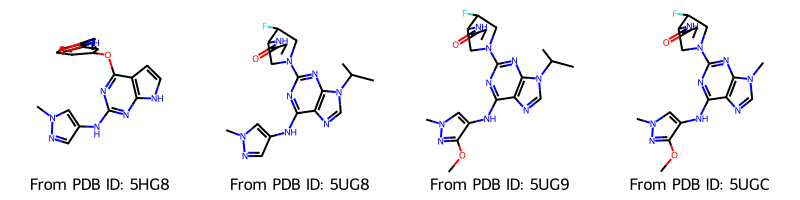

In [ ]:
Draw.MolsToGridImage(
    molecules,
    molsPerRow=4,
    legends=[f"From PDB ID: {pdb_id}" for pdb_id in pdb_ids],
)

이제 올바른 결합이 포함되었습니다.
우리는 또한 분자를 2D로 볼 수 있습니다. 원래 좌표를 유지하기 위해 2D 표현을 위한 사본을 만듭니다.

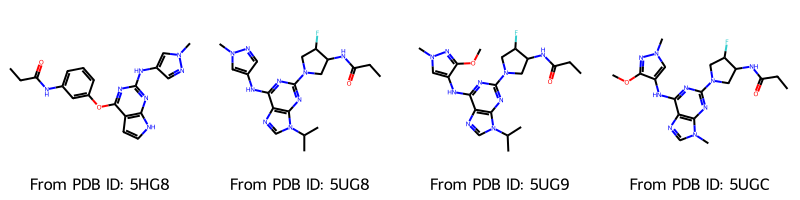

In [ ]:
molecules_2d = []
for molecule in molecules:
    tmp = Chem.Mol(molecule)
    AllChem.Compute2DCoords(tmp)
    molecules_2d.append(tmp)
Draw.MolsToGridImage(
    molecules_2d,
    molsPerRow=4,
    legends=[f"From PDB ID: {pdb_id}" for pdb_id in pdb_ids],
)

### `nglview`로 시각화

다음 단계에서 다음 함수를 사용하여 nglview로 리간드 분자를 시각화합니다.
분자들은 단일 뷰에서 서로 겹쳐서 그려집니다. 이렇게 하면 리간드 간의 구조적 차이를 시각적으로 비교할 수 있습니다.

In [ ]:
def _color_to_hex(color):
    """py3Dmol용 색 변환: "yellow" 같은 문자열은 그대로, (r,g,b) 0~1 튜플은 hex로."""
    if isinstance(color, str):
        return color
    return "#%02x%02x%02x" % tuple(int(round(255 * float(c))) for c in color)


def show_ligands(molecules):
    """Generate a view of the ligand molecules.

    Parameters
    -----------
    molecules: list of rdkit.Chem.rdchem.Mol

    Returns
    ----------
    py3Dmol.view
    """
    view = py3Dmol.view(width=900, height=600)
    for molecule in molecules:
        view.addModel(Chem.MolToMolBlock(molecule), "mol")
    # 모든 리간드를 ball and stick으로 표시
    view.setStyle({}, {"stick": {"radius": 0.12}, "sphere": {"scale": 0.22}})
    view.zoomTo()
    return view

In [ ]:
view = show_ligands(molecules)
view.show()

### 약물작용점 특징 추출

위에서 설명했듯이, 이 talktorial의 목표는 리간드 세트에서 리간드 기반 앙상블 약물작용점을 생성하는 것입니다.
먼저, 리간드별로 약물작용점 특징을 추출해야 합니다.
따라서 특징 팩토리를 로드합니다. 기본 특징 정의를 사용합니다.

[화학적 특징과 약물작용점에 대한 RDKit 문서](https://rdkit.readthedocs.io/en/latest/GettingStartedInPython.html#chemical-features-and-pharmacophores)도 참조하세요.

In [ ]:
feature_factory = AllChem.BuildFeatureFactory(str(Path(RDConfig.RDDataDir) / "BaseFeatures.fdef"))

RDKit에 구현된 약물작용점 특징들을 살펴봅니다:

In [ ]:
list(feature_factory.GetFeatureDefs().keys())

['Donor.SingleAtomDonor',
 'Acceptor.SingleAtomAcceptor',
 'NegIonizable.AcidicGroup',
 'PosIonizable.BasicGroup',
 'PosIonizable.PosN',
 'PosIonizable.Imidazole',
 'PosIonizable.Guanidine',
 'ZnBinder.ZnBinder1',
 'ZnBinder.ZnBinder2',
 'ZnBinder.ZnBinder3',
 'ZnBinder.ZnBinder4',
 'ZnBinder.ZnBinder5',
 'ZnBinder.ZnBinder6',
 'Aromatic.Arom4',
 'Aromatic.Arom5',
 'Aromatic.Arom6',
 'Aromatic.Arom7',
 'Aromatic.Arom8',
 'Hydrophobe.ThreeWayAttach',
 'Hydrophobe.ChainTwoWayAttach',
 'LumpedHydrophobe.Nitro2',
 'LumpedHydrophobe.RH6_6',
 'LumpedHydrophobe.RH5_5',
 'LumpedHydrophobe.RH4_4',
 'LumpedHydrophobe.RH3_3',
 'LumpedHydrophobe.tButyl',
 'LumpedHydrophobe.iPropyl']

예시로, 첫 번째 분자에서 모든 특징을 추출합니다.

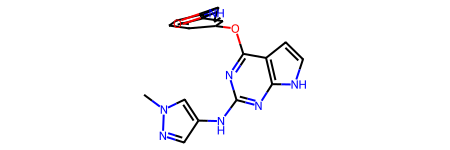

In [ ]:
example_molecule = molecules[0]
example_molecule

In [ ]:
# NBVAL_CHECK_OUTPUT
features = feature_factory.GetFeaturesForMol(example_molecule)
print(f"Number of features found: {len(features)}")

Number of features found: 16


특징의 유형은 RDKit에서 패밀리라고 불리며 `GetFamily()`로 가져올 수 있습니다.

In [ ]:
# NBVAL_CHECK_OUTPUT
features[0].GetFamily()

'Donor'

먼저 예시 분자에 대한 특징 유형의 빈도를 구합니다.

In [ ]:
# NBVAL_CHECK_OUTPUT
feature_frequency = collections.Counter(sorted([feature.GetFamily() for feature in features]))
feature_frequency

Counter({'Acceptor': 5,
         'Aromatic': 4,
         'Donor': 4,
         'Hydrophobe': 2,
         'LumpedHydrophobe': 1})

이제 위에 표시된 함수를 리간드 세트의 모든 분자에 적용합니다.
분자당 특징 유형 빈도를 계산한 다음 DataFrame에 표시합니다.

In [ ]:
molecule_feature_frequencies = []
for molecule in molecules:
    features = [feature.GetFamily() for feature in feature_factory.GetFeaturesForMol(molecule)]
    feature_frequency = collections.Counter(features)
    molecule_feature_frequencies.append(feature_frequency)

feature_frequencies_df = (
    pd.DataFrame(
        molecule_feature_frequencies,
        index=[f"Mol{i}" for i, _ in enumerate(molecules, 1)],
    )
    .fillna(0)
    .astype(int)
)
feature_frequencies_df.transpose()

,Mol1,Mol2,Mol3,Mol4
Donor,4,2,2,2
Acceptor,5,6,7,7
Aromatic,4,3,3,3
Hydrophobe,2,1,1,1
LumpedHydrophobe,1,1,1,0
PosIonizable,0,1,1,1


더 나아가, 이 talktorial에서는 다음 특징 유형에만 집중합니다: 수소결합 수용체(acceptors), 수소결합 공여체(donors), 그리고 소수성 접촉(hydrophobics).

특징 유형별 및 분자별로 특징 RDKit 객체를 가져옵니다.

In [ ]:
acceptors = []
donors = []
hydrophobics = []

for molecule in molecules:
    acceptors.append(feature_factory.GetFeaturesForMol(molecule, includeOnly="Acceptor"))
    donors.append(feature_factory.GetFeaturesForMol(molecule, includeOnly="Donor"))
    hydrophobics.append(feature_factory.GetFeaturesForMol(molecule, includeOnly="Hydrophobe"))

features = {
    "donors": donors,
    "acceptors": acceptors,
    "hydrophobics": hydrophobics,
}

### 모든 리간드의 약물작용점 특징 표시

약물작용점 특징 유형은 일반적으로 정의된 색상으로 표시되며, 예를 들어 수소결합 공여체, 수소결합 수용체, 소수성 접촉은 일반적으로 각각 녹색, 빨간색, 노란색으로 색칠됩니다.

In [ ]:
feature_colors = {
    "donors": (0, 0.9, 0),  # Green
    "acceptors": (0.9, 0, 0),  # Red
    "hydrophobics": (1, 0.9, 0),  # Yellow
}

In [ ]:
def visualize_features(
    molecules,
    features,
    feature_type="features",
    color="yellow",
    sphere_radius=0.5,
):
    """Generate a view of the molecules highlighting the specified feature type.

    Parameters
    -----------
    molecules: list of rdkit.Chem.rdchem.Mol
        molecules to be visualized
    features: list of tuples of rdkit.Chem.rdMolChemicalFeatures.MolChemicalFeature
        extracted features from molecules chosen to be highlighted
    feature_type: string, optional
        name of the feature to be highlighted
    color: string or (r, g, b) tuple, optional
        color used to display the highlighted features
    sphere_radius: float, optional
        display size of the highlighted features

    Returns
    ----------
    py3Dmol.view
    """
    print(f"Number of {feature_type} in all ligands: {sum([len(i) for i in features])}")
    view = show_ligands(molecules)
    hex_color = _color_to_hex(color)
    for i, feature_set in enumerate(features, 1):
        for feature in feature_set:
            loc = list(feature.GetPos())
            view.addSphere(
                {
                    "center": {"x": float(loc[0]), "y": float(loc[1]), "z": float(loc[2])},
                    "radius": float(sphere_radius),
                    "color": hex_color,
                    "opacity": 0.85,
                }
            )
    return view

이 함수를 사용하여 고려 중인 특징 유형의 특징을 시각화합니다.

#### 수소결합 공여체

In [ ]:
feature_type = "donors"
view = visualize_features(
    molecules,
    features[feature_type],
    feature_type,
    feature_colors[feature_type],
)
view.show()

#### 수소결합 수용체

In [ ]:
feature_type = "acceptors"
view = visualize_features(
    molecules,
    features[feature_type],
    feature_type,
    feature_colors[feature_type],
)
view.show()

#### 소수성 접촉

In [ ]:
feature_type = "hydrophobics"
view = visualize_features(
    molecules,
    features[feature_type],
    feature_type,
    feature_colors[feature_type],
)
view.show()

### 특징 유형별 특징 좌표 수집

특징 유형별로 특징을 클러스터링하려고 합니다. 이를 위해 모든 특징의 좌표를 수집하고 특징 유형별로 저장합니다.

In [ ]:
features_coord = {
    "donors": [list(item.GetPos()) for sublist in features["donors"] for item in sublist],
    "acceptors": [list(item.GetPos()) for sublist in features["acceptors"] for item in sublist],
    "hydrophobics": [
        list(item.GetPos()) for sublist in features["hydrophobics"] for item in sublist
    ],
}

이제 모든 수용체 특징의 위치를 가지고 있습니다:

In [ ]:
features_coord["acceptors"]

[[-13.49, 14.732, -27.925],
 [-11.99, 13.164, -28.961],
 [-13.173, 17.112, -28.025],
 [-16.131, 17.359, -22.003],
 [-16.873, 11.631, -25.856],
 [-13.808, 14.802, -27.137],
 [-12.146, 16.255, -28.067],
 [-11.385, 12.957, -29.278],
 [-16.736, 10.854, -25.879],
 [-15.435, 19.394, -27.21],
 [-16.039, 17.251, -22.54],
 [-13.863, 14.66, -27.134],
 [-12.175, 16.118, -27.994],
 [-11.411, 12.856, -29.266],
 [-17.026, 10.809, -26.396],
 [-15.601, 9.901, -28.086],
 [-15.445, 19.229, -27.215],
 [-16.044, 17.165, -22.506],
 [-13.831, 14.581, -27.162],
 [-12.161, 16.037, -28.079],
 [-11.381, 12.733, -29.268],
 [-17.02, 10.739, -26.48],
 [-15.542, 9.814, -28.111],
 [-15.515, 19.1, -27.334],
 [-16.09, 17.203, -22.553]]

### Generate ensemble pharmacophores

In order to generate ensemble pharmacophores, we use k-means clustering to cluster features per feature type.

#### Set static parameters for k-means clustering

* `kq`: With this paramter, we determine the number of clusters `k` per feature type depending on the number of feature points, i.e. per feature type
* `k` = number_of_features / `kq`
* `kq` should be selected so that `k` (feature clusters) is for all clusters at least 1 and not larger than 4-5 clusters

We set our `kq` used to determine `k` in k-means as follows:

In [ ]:
kq = 7

#### Set static parameters for cluster selection

* `min_cluster_size`: We only want to retain clusters that potentially contain features from most molecules in our ligand ensemble. Therefore, we set this variable to 75% of the number of molecules in our ligand ensemble.
* `top_cluster_number`: With this parameter, we select only the largest clusters.

In [ ]:
min_cluster_size = int(len(molecules) * 0.75)
top_cluster_number = 4

#### Define k-means clustering and cluster selection functions

We define a function that calculates the centers of clusters, which are derived from k-means clustering.

In [ ]:
def clustering(feature_coord, kq):
    """
    Compute the k-means clustering of input feature coordinates.

    Parameters
    -----------
    feature_coord: list
        feature coordinates extracted from the features of a set of molecules
    kq: int
        Quotient used when calculating number of features k

    Returns
    ----------
    sklearn.cluster._kmeans.KMeans
    """
    # Define parameter k as feature number divided by "k quotient"
    k = math.ceil(len(feature_coord) / kq)
    # Tailor-made adaption of k for hydrophobics in for the example in this talktorial
    k = 2 if k == 1 else k
    print(f"Clustering: \nVariable k in k-means: {k} of {len(feature_coord)} points\n")

    # Initialize k-means and compute clustering
    k_means = cluster.KMeans(n_clusters=k, n_init=10)
    k_means.fit(feature_coord)

    return k_means

We define a function that sorts the clusters by size and outputs a list of indices of the largest clusters.

In [ ]:
def get_clusters(k_means, min_cluster_size, top_cluster_number):
    """
    Select clusters from a k-means clustering and returns the indices of the selected clusters.
    The selection is based on cluster size. The largest clusters are chosen.

    Parameters
    -----------
    k_means: sklearn.cluster._kmeans.KMeans
        k-means clustering of feature coordinates
    min_cluster_size: int
        minimum size needed for a cluster to be viable for selection
    top_cluster_number: int
        number of clusters to be selected

    Returns
    ----------
    list of int
        indices of selected clusters
    """

    # Sort clusters by size and only show largest
    feature_labels = k_means.labels_

    feature_labels_count = Counter(feature_labels)

    feature_labels_count = sorted(
        feature_labels_count.items(), key=operator.itemgetter(1), reverse=True
    )
    print(f"Clusters sorted by size: \n{feature_labels_count}\n")

    # Get number of the largest clusters, which are larger then the threshold (selected clusters)
    cluster_indices_sel = []

    for cluster_index, cluster_size in feature_labels_count:
        if cluster_size >= min_cluster_size and top_cluster_number > 0:
            cluster_indices_sel.append(cluster_index)
            top_cluster_number -= 1

    print(f"Cluster indices of selected clusters: \n{cluster_indices_sel}\n")

    return cluster_indices_sel

#### Cluster features

For each feature type, we perform the k-means clustering with our defined `clustering` function.

In [ ]:
k_means = {
    "donors": clustering(features_coord["donors"], kq),
    "acceptors": clustering(features_coord["acceptors"], kq),
    "hydrophobics": clustering(features_coord["hydrophobics"], kq),
}

Clustering: 
Variable k in k-means: 2 of 10 points

Clustering: 
Variable k in k-means: 4 of 25 points

Clustering: 
Variable k in k-means: 2 of 5 points



#### Select relevant clusters

For each feature type, we select relevant clusters with our defined `get_clusters` function.

In [ ]:
print("Hydrogen bond donors\n")
cluster_indices_sel_donors = get_clusters(k_means["donors"], min_cluster_size, top_cluster_number)

Hydrogen bond donors

Clusters sorted by size: 
[(0, 6), (1, 4)]

Cluster indices of selected clusters: 
[0, 1]



In [ ]:
print("Hydrogen bond acceptors\n")
cluster_indices_sel_acceptors = get_clusters(
    k_means["acceptors"], min_cluster_size, top_cluster_number
)

Hydrogen bond acceptors

Clusters sorted by size: 
[(1, 12), (2, 6), (0, 4), (3, 3)]

Cluster indices of selected clusters: 
[1, 2, 0, 3]



In [ ]:
print("Hydrophobic contacts\n")
cluster_indices_sel_hydrophobic = get_clusters(
    k_means["hydrophobics"], min_cluster_size, top_cluster_number
)

Hydrophobic contacts

Clusters sorted by size: 
[(0, 4), (1, 1)]

Cluster indices of selected clusters: 
[0]



In [ ]:
cluster_indices_sel = {
    "donors": cluster_indices_sel_donors,
    "acceptors": cluster_indices_sel_acceptors,
    "hydrophobics": cluster_indices_sel_hydrophobic,
}

#### Get selected cluster coordinates

In [ ]:
def get_selected_cluster_center_coords(k_means, cluster_indices_sel):
    """Retrieve cluster center coordinates for selected clusters.
    The selected clusters are defined by their indices.

    Parameters
    -----------
    k_means: sklearn.cluster._kmeans.KMeans
        k-means clustering of feature coordinates
    cluster_indices_sel: list of int
        indices of the chosen clusters

    Returns
    ----------
    two-dimensional list of floats
        cluster center coordinates
    """
    cluster_centers = k_means.cluster_centers_

    # Cast to list and then to pandas Series (for element selection by indices)
    cluster_centers = pd.Series(cluster_centers.tolist())

    # Select cluster centers by indices of selected clusters
    cluster_centers_sel = cluster_centers[cluster_indices_sel]

    return list(cluster_centers_sel)

In [ ]:
cluster_centers_sel = {
    "donors": get_selected_cluster_center_coords(k_means["donors"], cluster_indices_sel["donors"]),
    "acceptors": get_selected_cluster_center_coords(
        k_means["acceptors"], cluster_indices_sel["acceptors"]
    ),
    "hydrophobics": get_selected_cluster_center_coords(
        k_means["hydrophobics"], cluster_indices_sel["hydrophobics"]
    ),
}

In [ ]:
cluster_centers_sel["acceptors"]

[[-12.567833333333333, 14.66725, -28.191333333333333],
 [-16.466333333333335, 10.624666666666666, -26.801333333333332],
 [-16.076, 17.244500000000002, -22.4005],
 [-15.465, 19.241, -27.253]]

### Show clusters

Per feature type, we visualize cluster centers alongside with all molecules and all feature points.

In [ ]:
def visualize_clusters(
    molecules,
    features,
    clusters,
    feature_type="features",
    color="yellow",
    feature_radius=0.5,
    cluster_radius=1,
):
    """Visualize the cluster centers.

    Parameters
    -----------
     molecules: list of rdkit.Chem.rdchem.Mol
        molecules to be visualized
    features: list of tuples of rdkit.Chem.rdMolChemicalFeatures.MolChemicalFeature
        extracted features from molecules chosen to be highlighted
    clusters: Two-dimensional list of floats
        cluster center coordinates
    feature_type: string, optional
        feature type being visualized
    color: string or (r, g, b) tuple, optional
        color used for rendering the features and cluster centers
    feature_radius: float, optional
        rendering size of the features
    cluster_radius: float, optional
        rendering size of the cluster centers

    Returns
    ----------
    py3Dmol.view
    """
    view = visualize_features(
        molecules,
        features,
        feature_type,
        color=color,
        sphere_radius=feature_radius,
    )
    hex_color = _color_to_hex(color)
    for i, center in enumerate(clusters, 1):
        loc = list(center)
        # 클러스터 중심은 더 크고 반투명한 구로 표시
        view.addSphere(
            {
                "center": {"x": float(loc[0]), "y": float(loc[1]), "z": float(loc[2])},
                "radius": float(cluster_radius),
                "color": hex_color,
                "opacity": 0.5,
            }
        )
    return view

#### Hydrogen bond donors

In [ ]:
feature_type = "donors"
view = visualize_clusters(
    molecules,
    features[feature_type],
    cluster_centers_sel[feature_type],
    feature_type,
    feature_colors[feature_type],
)
view.show()

#### Hydrogen bond acceptor

In [ ]:
feature_type = "acceptors"
view = visualize_clusters(
    molecules,
    features[feature_type],
    cluster_centers_sel[feature_type],
    feature_type,
    feature_colors[feature_type],
)
view.show()

#### Hydrophobic contacts

In [ ]:
feature_type = "hydrophobics"
view = visualize_clusters(
    molecules,
    features[feature_type],
    cluster_centers_sel[feature_type],
    feature_type,
    feature_colors[feature_type],
)
view.show()

### Show ensemble pharmacophore

In this last step, we combine the clustered pharmacophoric features (i.e. hydrogen bond donors and acceptors as well as hydrophobic contacts), to one ensemble pharmacophore, representing the pharmacophoric properties of the four selected ligands.

In [ ]:
view = show_ligands(molecules)
# Load clusters
for feature_type in cluster_indices_sel.keys():
    centers = cluster_centers_sel[feature_type]
    feature_color = _color_to_hex(feature_colors[feature_type])
    for i, loc in enumerate(centers):
        sphere_radius = 1
        view.addSphere(
            {
                "center": {"x": float(loc[0]), "y": float(loc[1]), "z": float(loc[2])},
                "radius": float(sphere_radius),
                "color": feature_color,
                "opacity": 0.6,
            }
        )
view.show()

## 토론

이 talktorial에서는 EGFR에 결합하는 것으로 알려진 미리 정렬된 리간드 세트를 사용하여 앙상블 약물작용점 모델을 생성했습니다. 이 모델은 이제 대규모 작은 분자 라이브러리에 대한 가상 스크리닝에 사용되어 관찰된 입체 및 물리화학적 특성을 보이고 따라서 EGFR 결합 부위에도 결합할 수 있는 새로운 작은 분자를 찾을 수 있습니다.

스크리닝 전에 약물작용점 모델은 일반적으로 더 최적화됩니다. 예를 들어 생물학적 지식(일부 상호작용은 중요하다고 보고되지만 다른 것들은 그렇지 않을 수 있음)이나 화학적 전문지식에 기반하여 스크리닝을 위한 특징 수를 줄이기 위해 특징을 생략할 수 있습니다.

이 talktorial에서는 가상 스크리닝을 다루지 않지만, RDKit을 사용한 약물작용점 모델링과 가상 스크리닝을 보여주는 Nik Stiefl의 훌륭한 튜토리얼을 참조합니다 ([GitHub의 RDKit UGM 2016](https://github.com/rdkit/UGM_2016/blob/master/Notebooks/Stiefl_RDKitPh4FullPublication.ipynb)).

우리는 약물작용점 특징을 클러스터링하기 위해 k-means 클러스터링을 사용했습니다. 이 클러스터링 접근법은 사용자가 사전에 클러스터 수를 정의해야 한다는 단점이 있으며, 이는 일반적으로 클러스터링 전(또는 클러스터 정제 중) 점 분포의 시각적 검사에 기반하므로 자동화된 약물작용점 생성에 방해가 됩니다. k-means 클러스터링과의 조합으로도 밀도 기반 클러스터링 방법이 이에 대한 해결책이 될 수 있습니다. 추가 읽기를 위해 [Domino Data Lab의 밀도 기반 클러스터링 소개](https://blog.dominodatalab.com/topology-and-density-based-clustering/)를 추천합니다.

## 퀴즈

1. 약물작용점 특징과 약물작용점이라는 용어를 설명하세요.
2. 구조 기반과 리간드 기반 약물작용점 모델링의 차이점을 설명하세요.
3. 어떻게 앙상블 약물작용점을 도출했는지 설명하세요.